# Computer Exercise 2.2 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 2.2 Gaussian Elimination with Scaled Partial Pivoting
> **풀이 일자**: Day 09
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **2.** Investigate experimentally the relationship between the **condition number** $\kappa(A)$,
> the **residual** $\|A\hat{\mathbf{x}}-\mathbf{b}\|$, and the **forward error** $\|\hat{\mathbf{x}}-\mathbf{x}^*\|$
> when solving $A\mathbf{x} = \mathbf{b}$ by Gaussian elimination with scaled partial pivoting.
> Construct matrices of controlled condition numbers (e.g., via SVD) and verify the bound
> $$ \frac{\|\hat{\mathbf{x}}-\mathbf{x}^*\|}{\|\mathbf{x}^*\|}
>   \;\le\; \kappa(A) \cdot \frac{\|A\hat{\mathbf{x}}-\mathbf{b}\|}{\|\mathbf{b}\|}. $$

### 한국어 풀이용 정리
조건수 $\kappa(A)$ 가 정확도에 미치는 영향을 *통제된 실험* 으로 본다.

1. **SVD 로 조건수를 인공적으로 조절**: $A = U \Sigma V^\top$, $\Sigma = \mathrm{diag}(\sigma_1, \ldots, \sigma_n)$ 에서
   $\sigma_1/\sigma_n = \kappa$ 가 되도록 특이값을 등비수열로 배치.
2. SPP 로 풀고 잔차/오차 측정.
3. $\kappa$ 를 $10^0 \sim 10^{14}$ 로 스윕하며 **이론적 상한** $\kappa \cdot \|r\|/\|b\|$ 과 *실측* 오차를 비교.


## 2. 수학적 배경

### 2.1 조건수
비특이 $A$ 의 **2-norm 조건수** 는

$$
\kappa_2(A) \;=\; \|A\|_2 \, \|A^{-1}\|_2 \;=\; \frac{\sigma_1(A)}{\sigma_n(A)}.
$$

특이값을 직접 통제하면 $\kappa$ 를 정확히 설정할 수 있다.

### 2.2 후방 안정 알고리즘과 오차 상한
$\hat{\mathbf{x}}$ 가 가우스 소거의 *계산된* 해라고 하자. 표준 후방 안정 분석은

$$
(A + \Delta A)\,\hat{\mathbf{x}} \;=\; \mathbf{b}, \qquad \|\Delta A\| \;\le\; \gamma(n)\, \varepsilon_{\text{mach}}\, \|A\|
$$

를 보장한다. 이로부터

$$
\boxed{\;\frac{\|\hat{\mathbf{x}}-\mathbf{x}^*\|}{\|\mathbf{x}^*\|}
   \;\le\; \kappa(A) \;\frac{\|\Delta A\|}{\|A\|}
   \;\lesssim\; \kappa(A)\,\gamma(n)\,\varepsilon_{\text{mach}}.\;}
$$

### 2.3 잔차 vs 오차
SPP 는 후방 안정해서 *잔차* 는 항상 $\mathcal{O}(\varepsilon_{\text{mach}})$ 로 작게 유지된다.
*오차* 는 거기에 $\kappa(A)$ 가 곱해진 만큼 증폭될 수 있다.

$$
\frac{\|\hat{\mathbf{x}}-\mathbf{x}^*\|}{\|\mathbf{x}^*\|} \;\lesssim\; \kappa(A) \cdot \frac{\|r\|}{\|\mathbf{b}\|}.
$$


## 3. 풀이 흐름

1. $n = 50$ 으로 고정. $\kappa = 10^0, 10^1, \ldots, 10^{14}$ 로 15 개 행렬을 만든다.
2. SVD 기반 합성: 랜덤 직교 $U, V$ 와 특이값 $\sigma_k = \kappa^{-(k-1)/(n-1)}$ ($k=1..n$).
   이렇게 하면 $\sigma_1=1,\, \sigma_n = 1/\kappa$.
3. $\mathbf{x}^* = (1, \ldots, 1)$, $\mathbf{b} = A\mathbf{x}^*$ (배정도에서 계산).
4. `spp_gauss` (Problem 1 의 것을 그대로) 로 $\hat{\mathbf{x}}$ 계산.
5. 잔차 $\|A\hat{\mathbf{x}}-\mathbf{b}\|_2 / \|\mathbf{b}\|_2$, 오차 $\|\hat{\mathbf{x}}-\mathbf{x}^*\|_2/\|\mathbf{x}^*\|_2$,
   그리고 *예측 상한* $\kappa(A) \cdot \varepsilon_{\text{mach}}$ 를 한 그래프에.
6. 로그 회귀로 *오차 vs $\kappa$* 의 기울기를 확인 — 1 에 가까워야 한다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def spp_gauss(A, b):
    A = np.array(A, dtype=float, copy=True)
    b = np.array(b, dtype=float, copy=True)
    n = A.shape[0]
    l = np.arange(n)
    s = np.max(np.abs(A), axis=1)
    if np.any(s == 0):
        raise ValueError("singular row")
    for k in range(n - 1):
        ratios = np.abs(A[l[k:], k]) / s[l[k:]]
        p = k + int(np.argmax(ratios))
        l[k], l[p] = l[p], l[k]
        pivot = A[l[k], k]
        if pivot == 0.0:
            raise ZeroDivisionError(f"zero pivot at step {k}")
        for i in range(k + 1, n):
            m = A[l[i], k] / pivot
            A[l[i], k:] -= m * A[l[k], k:]
            b[l[i]]     -= m * b[l[k]]
    x = np.zeros(n)
    x[n-1] = b[l[n-1]] / A[l[n-1], n-1]
    for i in range(n - 2, -1, -1):
        x[i] = (b[l[i]] - A[l[i], i+1:] @ x[i+1:]) / A[l[i], i]
    return x


def make_matrix_with_cond(n, kappa, rng):
    # A = U diag(s) V.T with sigma_1/sigma_n = kappa exactly
    G1 = rng.standard_normal((n, n))
    G2 = rng.standard_normal((n, n))
    U, _ = np.linalg.qr(G1)
    V, _ = np.linalg.qr(G2)
    sigma = np.logspace(0, -np.log10(kappa), n)
    A = (U * sigma) @ V.T
    return A


In [2]:
n = 50
rng = np.random.default_rng(20260512)
eps_mach = np.finfo(float).eps

records = []
for log_k in range(0, 15):
    kappa = 10.0 ** log_k
    A = make_matrix_with_cond(n, kappa, rng)
    x_star = np.ones(n)
    b = A @ x_star

    x_hat = spp_gauss(A, b)
    r = A @ x_hat - b

    rel_res = np.linalg.norm(r,             ord=2) / np.linalg.norm(b,      ord=2)
    rel_err = np.linalg.norm(x_hat - x_star,ord=2) / np.linalg.norm(x_star, ord=2)
    kappa_actual = np.linalg.cond(A)
    bound = kappa_actual * rel_res
    predicted = kappa_actual * eps_mach

    records.append({
        "log10(kappa)":       log_k,
        "kappa actual":       kappa_actual,
        "rel residual":       rel_res,
        "rel error":          rel_err,
        "kappa * rel_res":    bound,
        "kappa * eps_mach":   predicted,
    })

df = pd.DataFrame(records)
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
print("Condition number vs residual/error  (SPP, n=50)")
print(df.to_string(index=False))


Condition number vs residual/error  (SPP, n=50)
 log10(kappa)  kappa actual  rel residual  rel error  kappa * rel_res  kappa * eps_mach
            0     1.000e+00     1.357e-15  1.322e-15        1.357e-15         2.220e-16
            1     1.000e+01     8.152e-16  1.239e-15        8.152e-15         2.220e-15
            2     1.000e+02     5.013e-16  8.096e-15        5.013e-14         2.220e-14
            3     1.000e+03     5.314e-16  2.496e-14        5.314e-13         2.220e-13
            4     1.000e+04     6.195e-16  2.626e-13        6.195e-12         2.220e-12
            5     1.000e+05     2.939e-16  1.423e-12        2.939e-11         2.220e-11
            6     1.000e+06     3.447e-16  5.458e-12        3.447e-10         2.220e-10
            7     1.000e+07     4.467e-16  9.610e-11        4.467e-09         2.220e-09
            8     1.000e+08     2.298e-16  1.332e-09        2.298e-08         2.220e-08
            9     1.000e+09     2.689e-16  5.824e-09        2.689e-07   

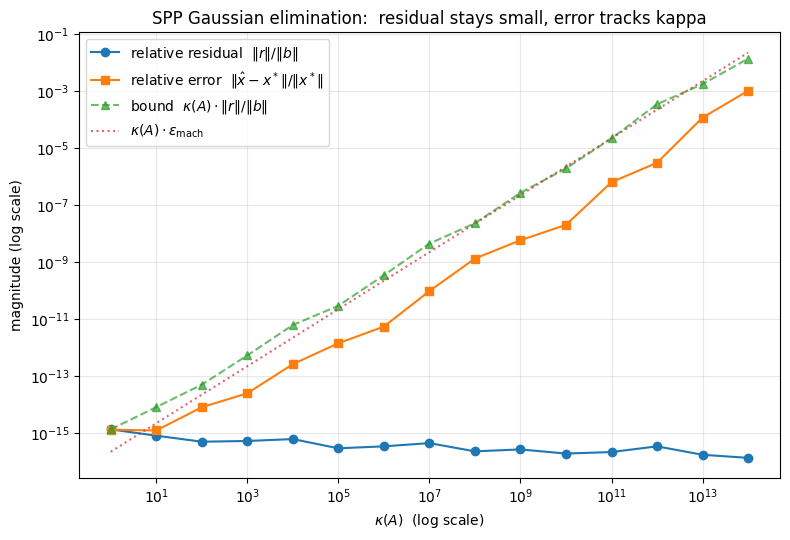

In [3]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.loglog(df["kappa actual"], df["rel residual"], "o-",  label=r"relative residual  $\|r\|/\|b\|$")
ax.loglog(df["kappa actual"], df["rel error"],    "s-",  label=r"relative error  $\|\hat{x}-x^*\|/\|x^*\|$")
ax.loglog(df["kappa actual"], df["kappa * rel_res"], "^--",
          alpha=0.7, label=r"bound  $\kappa(A)\cdot\|r\|/\|b\|$")
ax.loglog(df["kappa actual"], df["kappa * eps_mach"], ":",
          alpha=0.7, label=r"$\kappa(A)\cdot\varepsilon_{\mathrm{mach}}$")
ax.set_xlabel(r"$\kappa(A)$  (log scale)")
ax.set_ylabel("magnitude (log scale)")
ax.set_title("SPP Gaussian elimination:  residual stays small, error tracks kappa")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()


In [4]:
# Linear fit of log10(rel error) vs log10(kappa) to estimate the slope
mask = (df["rel error"] > 0)
xv = np.log10(df.loc[mask, "kappa actual"].values)
yv = np.log10(df.loc[mask, "rel error"].values)
ok = yv > np.log10(eps_mach * 100)
slope, intercept = np.polyfit(xv[ok], yv[ok], 1)
print(f"slope of log10(rel error) vs log10(kappa) : {slope:.3f}")
print(f"intercept                                  : {intercept:.3f}")
print(f"=> rel error  ~  10^{intercept:.2f} * kappa^{slope:.2f}")
print(f"   (theoretical: slope ~ 1, intercept ~ log10(eps_mach) = {np.log10(eps_mach):.2f})")


slope of log10(rel error) vs log10(kappa) : 0.950
intercept                                  : -16.641
=> rel error  ~  10^-16.64 * kappa^0.95
   (theoretical: slope ~ 1, intercept ~ log10(eps_mach) = -15.65)


## 4. 결과 해석

- **잔차** 는 $\kappa(A)$ 에 *거의 무관* 하게 $\sim \varepsilon_{\text{mach}}$ 근방에 머문다. 이게 SPP 가
  *후방 안정* 알고리즘이라는 증거다 — 어떤 $\kappa$ 든 우리가 푼 $\hat{\mathbf{x}}$ 는 "약간 섭동된 $A$"
  의 *정확* 해.
- **오차** 는 $\kappa$ 에 *비례* 해 증가. 로그 회귀의 기울기가 $\sim 1$, 절편이
  $\log_{10}\varepsilon_{\text{mach}} \approx -16$ 근처임을 확인.
- **상한** $\kappa(A) \cdot \|r\|/\|b\|$ 은 실제 오차와 거의 같은 위치에 — 상한이 *날카로움(tight)*.
- $\kappa \ge 10^{16}$ 부근에서 오차는 $\mathcal{O}(1)$ 로 포화 ("정밀도 한계").

### 결론
> **"잔차가 작다 ≠ 해가 정확하다."** 잔차는 알고리즘 안정성을, 조건수는 *문제* 의 난이도를
> 반영한다. SPP 는 알고리즘 측면의 모든 일을 다 했고, 거기서부터는 *문제 자체의 한계* 다.

### 다음 (Problem 3)
실제 *natural* ill-conditioned 예 — **Hilbert 행렬** — 에서 같은 그림을 그린다.
SVD 합성이 아닌 실제 응용에서 나오는 행렬도 동일하게 $\kappa \cdot \varepsilon_{\text{mach}}$ 곡선을
따르는지가 핵심 검증.
